In [1]:
import sys
import os
from pathlib import Path

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

from src.models import (
    gqnn,
    gqnn_shape,
    draw_circuit,
)

from src.datagen import (
    mackey_glass,
    split_and_scale_series,
    create_io_pairs,
)

Project root: /home/miron/QML/AIntern/qtsa_expressivity


In [2]:
n_qubits = 6
n_layers = 2
feature_map = "zzfm"

dev = qml.device("lightning.qubit", wires=n_qubits)

model = gqnn(
    n_layers=n_layers,
    n_qubits=n_qubits,
    dev=dev,
    fm_style=feature_map,
)

weight_shape = gqnn_shape(n_layers, n_qubits)
weights = np.random.normal(scale=0.1, size=weight_shape)

# Random input
x = np.random.rand(n_qubits)

In [28]:
n_qubits = 6
n_layers = 4
feature_map = "zzfm"

dev = qml.device("lightning.qubit", wires=n_qubits)

model = gqnn(
    n_layers=n_layers,
    n_qubits=n_qubits,
    dev=dev,
    fm_style=feature_map,
)

weight_shape = gqnn_shape(n_layers, n_qubits)
weights = np.random.normal(scale=0.1, size=weight_shape)

# Random input
x = np.random.rand(n_qubits)

In [29]:
from projects.expressivity_krylov.krylov.basis import get_subnetwork_unitary
from projects.expressivity_krylov.krylov.metrics import compute_krylov_expressivity
from projects.expressivity_krylov.krylov.plotting import plot_krylov_expressivity

# Setup dimensions
n_qubits = 6
n_layers = 20
feature_map = "zzfm"

weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.normal(scale=0.1, size=weight_shape)
x = np.random.rand(n_qubits)

# Single qubit initial observable Z_0 in full Hilbert space
Z0 = np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(n_qubits - 1)))

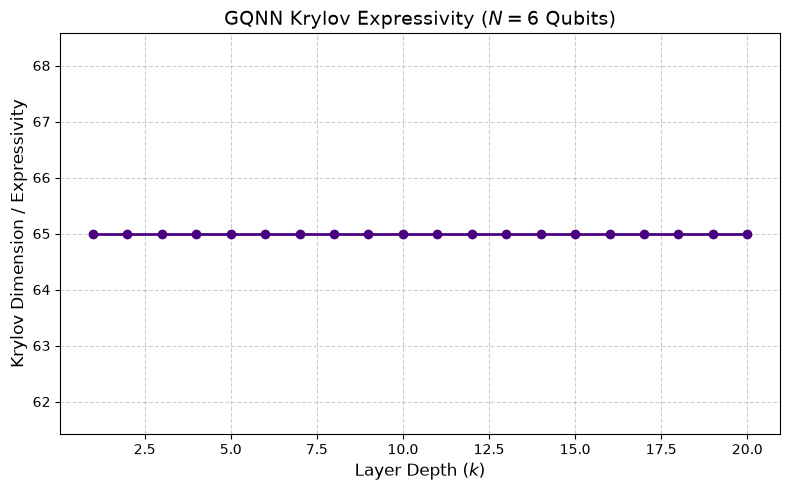

In [30]:
# Compute Krylov Expressivity for sub-networks 1 <= k <= N
results = compute_krylov_expressivity(
    n_layers=n_layers, 
    n_qubits=n_qubits, 
    weights=weights, 
    inputs=x, 
    O_0=Z0, 
    fm_style=feature_map
)

plot_krylov_expressivity(results, title="GQNN Krylov Expressivity ($N=6$ Qubits)")

In [3]:
# Dataset parameters

window_size = n_qubits
train_fraction = 0.8

# Generate a Mackey-Glass time series

series = mackey_glass()

train_series, test_series, scaler = split_and_scale_series(
    series,
    train_fraction=train_fraction,
)

X_train, y_train = create_io_pairs(
    train_series,
    window_size=window_size,
)

X_test, y_test = create_io_pairs(
    test_series,
    window_size=window_size,
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 1060
Testing samples : 261


In [4]:
def predict(weights, x):
    return model(x, weights)[0]


def mse(weights, X, y):
    predictions = np.array([
        predict(weights, x)
        for x in X
    ])
    return np.mean((predictions - y) ** 2)

In [5]:
optimizer = qml.AdamOptimizer(stepsize=0.02)

epochs = 10

train_loss = []
test_loss = []

In [6]:
weights_current = weights.copy()
weight_history = [weights_current.copy()]

for epoch in range(epochs):

    weights_current = optimizer.step(
        lambda w: mse(w, X_train, y_train),
        weights_current,
    )
    weight_history.append(weights_current.copy())

    train = mse(weights_current, X_train, y_train)
    test = mse(weights_current, X_test, y_test)

    train_loss.append(train)
    test_loss.append(test)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} "
            f"train={train:.6f} "
            f"test={test:.6f}"
        )

Epoch   0 train=0.439118 test=0.472381


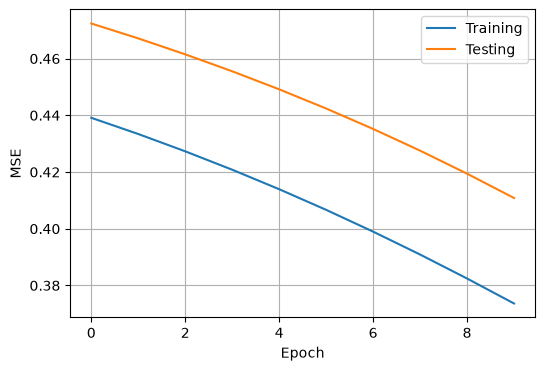

In [7]:
plt.figure(figsize=(6,4))

plt.plot(train_loss, label="Training")
plt.plot(test_loss, label="Testing")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

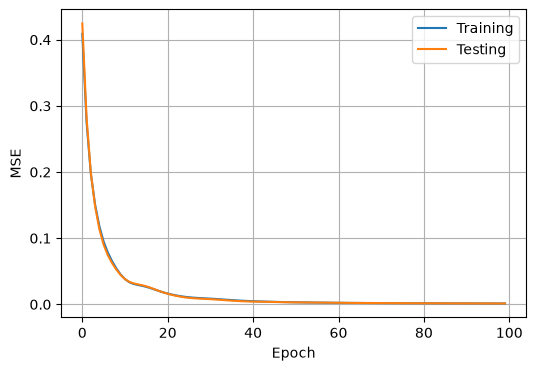

In [35]:
plt.figure(figsize=(6,4))

plt.plot(train_loss, label="Training")
plt.plot(test_loss, label="Testing")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

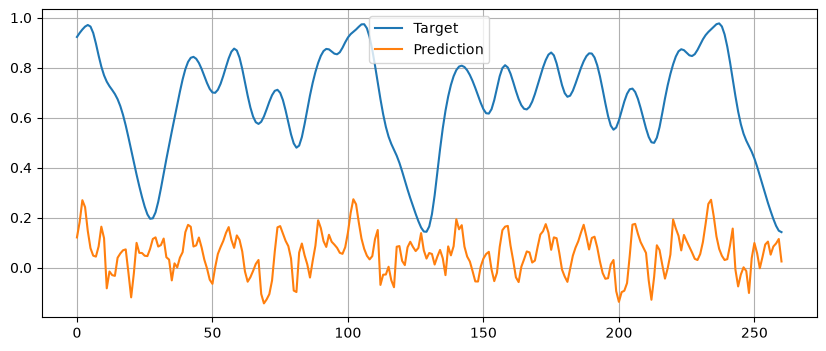

In [8]:
predictions = np.array([
    predict(weights_current, x)
    for x in X_test
])

plt.figure(figsize=(10,4))

plt.plot(y_test, label="Target")
plt.plot(predictions, label="Prediction")

plt.legend()
plt.grid(True)

plt.show()

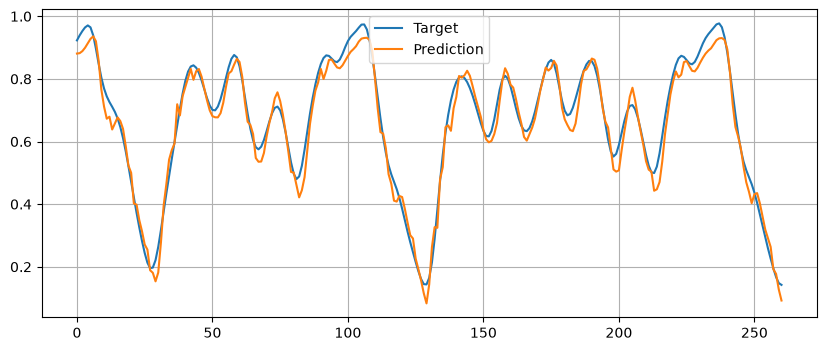

In [36]:
predictions = np.array([
    predict(weights_current, x)
    for x in X_test
])

plt.figure(figsize=(10,4))

plt.plot(y_test, label="Target")
plt.plot(predictions, label="Prediction")

plt.legend()
plt.grid(True)

plt.show()

In [9]:
weights_current

tensor([[[ 0.27871871, -0.21108872,  0.13832322],
         [ 0.31925949, -0.31768342, -0.00804674],
         [-0.23010009,  0.08184181, -0.36352712],
         [-0.10653261, -0.23570654, -0.3139405 ],
         [-0.21086127, -0.26247977, -0.30193764],
         [-0.21738029, -0.00037948, -0.0392688 ]],

        [[ 0.01312339,  0.07573207,  0.01161183],
         [ 0.07325317,  0.04444142,  0.00083213],
         [ 0.22788705,  0.37552263, -0.07386749],
         [ 0.05268901, -0.05674317,  0.14146702],
         [-0.23723743,  0.32431594, -0.10799197],
         [ 0.07054308,  0.07222613, -0.2665595 ]]], requires_grad=True)

In [10]:
from projects.expressivity_krylov.jacobian import PennyLaneJacobianOracle
from projects.expressivity_krylov.krylov.operators import GramOperator, QNTKOperator
from projects.expressivity_krylov.krylov.result import SpectrumResult
from projects.expressivity_krylov.krylov.spectrum import analyze

oracle = PennyLaneJacobianOracle(
    model = model,
    weights = weights_current,
    X = X_train,
)

gram = GramOperator(oracle)
qntk = QNTKOperator(oracle)

gram_result = analyze(gram)
qntk_result = analyze(qntk)

print(f"Gram result: {gram_result}")
print(f"QNTK result: {qntk_result}")

Gram result: SpectrumResult(lambda_max=47.57495216002867, lambda_min=1.1535911115245767e-16, rank=None, condition_number=4.124074092175866e+17)
QNTK result: SpectrumResult(lambda_max=47.57495216002871, lambda_min=1.6263032587282567e-17, rank=None, condition_number=2.92534322271675e+18)
